In [27]:
#For data handling and manipulation.
import pandas as pd
import numpy as np
# For data visualization.
import seaborn as sns
import matplotlib.pyplot as plt
# To split data and perform hyperparameter tuning.
from sklearn.model_selection import train_test_split, GridSearchCV
# To handle missing values.
from sklearn.impute import SimpleImputer
# For encoding categorical variables and scaling.
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
# To evaluate model performance.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Machine learning models
import lightgbm as lgb
import xgboost as xgb
#loading Titanic Dataset
train_df = pd.read_csv('/content/Titanic_train.csv')
test_df = pd.read_csv('/content/Titanic_test.csv')


In [28]:
#EDA process
print("Train Data Info:")
print(train_df.info())

print("Test Data Info:")
print(test_df.info())

print("\nMissing Values:")
print(train_df.isnull().sum())

print(test_df.isnull().sum())


Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
Test Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId 

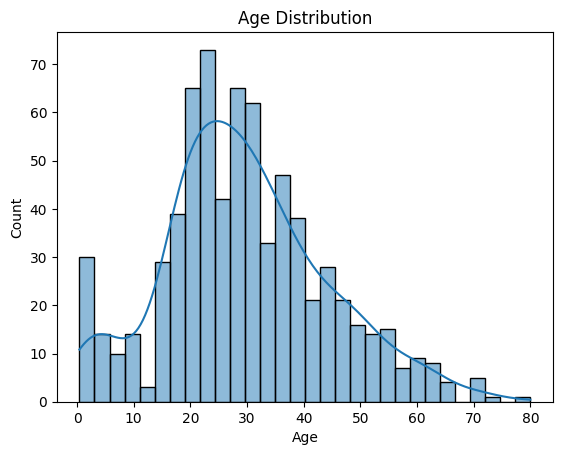

In [29]:
#Data Distribution Visualization
#Create a histogram of the Age column.
sns.histplot(train_df['Age'].dropna(), bins=30, kde=True)#(dropna(): Removes NaN values before plotting,kde=True: Adds a density curve for better visualization.)
plt.title("Age Distribution")
plt.show()


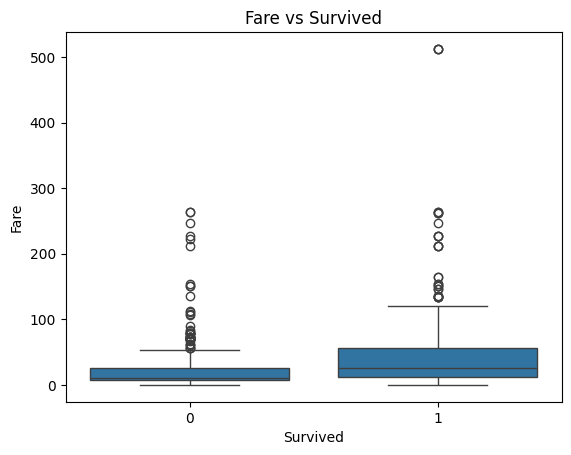

In [30]:
# Box plot to see the distribution of Fare prices for survivors vs. non-survivors.
sns.boxplot(x='Survived', y='Fare', data=train_df)
plt.title("Fare vs Survived")
plt.show()


In [32]:
#Data Preprocessing
#Handling Missing Values
imputer = SimpleImputer(strategy='median')#  Fills missing values in Age with the median.
train_df['Age'] = imputer.fit_transform(train_df[['Age']])
test_df['Age'] = imputer.transform(test_df[['Age']])
imputer = SimpleImputer(strategy='mean')# Fills missing values in Fare with the mean.
 # Check if 'Embarked' column exists before imputation
if 'Embarked' in train_df.columns:
    train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)# Fills missing values in Embarked with the most frequent value (mode()).
if 'Embarked' in test_df.columns:
    test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace=True)

# Ensure column names are correct before applying get_dummies
print(train_df.columns)  # Print columns to verify if 'Sex' and 'Embarked' exist

train_df = pd.get_dummies(train_df, columns=['Sex', 'Embarked'], drop_first=True) # Use existing column names 'Sex' and 'Embarked'
test_df = pd.get_dummies(test_df, columns=['Sex', 'Embarked'], drop_first=True)




Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


<ipython-input-32-2ad6bf18d063>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)# Fills missing values in Embarked with the most frequent value (mode()).
<ipython-input-32-2ad6bf18d063>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

In [35]:
# Feature Selection
features = ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S']
X = train_df[features]
y = train_df['Survived']

#Splitting Data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training & Evaluation Function
def evaluate_model(model, X_valid, y_valid):
    y_pred = model.predict(X_valid)
    y_pred = [1 if i > 0.5 else 0 for i in y_pred]
    print("Accuracy:", accuracy_score(y_valid, y_pred))
    print("Precision:", precision_score(y_valid, y_pred))
    print("Recall:", recall_score(y_valid, y_pred))
    print("F1-score:", f1_score(y_valid, y_pred))


In [44]:
#LightGBM Model
lgb_model = lgb.LGBMClassifier(
    max_depth=10,  # Increase depth to allow more splits
    min_child_samples=5,  # Reduce minimum samples per leaf
    learning_rate=0.05,  # Adjust learning rate
    n_estimators=200  # Increase trees for better performance
)
lgb_model.fit(X_train, y_train)
print("LightGBM Performance:")
evaluate_model(lgb_model, X_valid, y_valid)



[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 195
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [45]:
#XGBoost Model
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)
print("XGBoost Performance:")
evaluate_model(xgb_model, X_valid, y_valid)


XGBoost Performance:
Accuracy: 0.7988826815642458
Precision: 0.7567567567567568
Recall: 0.7567567567567568
F1-score: 0.7567567567567568


In [49]:
models = ['LightGBM', 'XGBoost']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
results = {
    'LightGBM': [accuracy_score(y_valid, lgb_model.predict(X_valid)),
                 precision_score(y_valid, lgb_model.predict(X_valid)),
                 recall_score(y_valid, lgb_model.predict(X_valid)),
                 f1_score(y_valid, lgb_model.predict(X_valid))],
    'XGBoost': [accuracy_score(y_valid, xgb_model.predict(X_valid)),
                precision_score(y_valid, xgb_model.predict(X_valid)),
                recall_score(y_valid, xgb_model.predict(X_valid)),
                f1_score(y_valid, xgb_model.predict(X_valid))]
}
results_df = pd.DataFrame(results, index=metrics)
print(results_df)


           LightGBM   XGBoost
Accuracy   0.826816  0.798883
Precision  0.802817  0.756757
Recall     0.770270  0.756757
F1-score   0.786207  0.756757


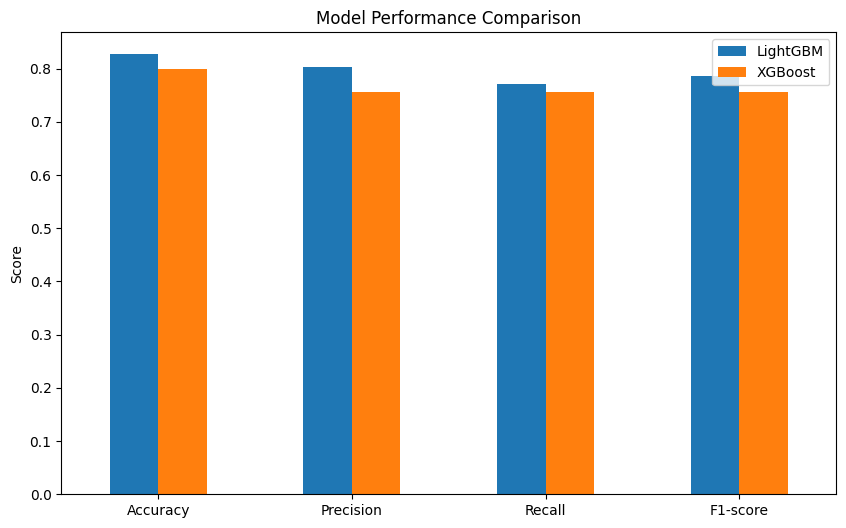

In [51]:
#visuals of result
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


Conclusion of the script:
* Loads and preprocesses the Titanic dataset.
* Trains LightGBM and XGBoost models.
* Evaluates model performance using accuracy, precision, recall, and F1-score.
* Compares and visualizes the results.